# Labs 1

In [165]:
from matplotlib import pyplot as plt

import random
import numpy.random as rng
import numpy as np

## Task 1: Generate random numbers
Using numpy.random (or whatever you like), generate:

*	An integer random number in a range [0,5] (using random.integers)
*	100 float random numbers in a range [0,5] (using random.uniform)
*	A 3x3 matrix of floats random number in a range [0,2]

Try using seed and without seed to see the difference.

no seed

In [166]:
rand_int = random.randint(0, 5)

print(rand_int)

rand_float = random.uniform(0, 5)

print(rand_float)

matrix = []
width = 3
height = 3

for x in range(width):
    row = []
    for y in range(height):
        row.append(random.uniform(0, 2))

    matrix.append(row)

print(matrix)

1
2.526776440516812
[[0.05307193936772725, 0.397675301373297, 1.2997688755590464], [1.0898829612064334, 0.4408812440813934, 1.1785313677518174], [1.6188609133556533, 0.012997519356122034, 1.6116385036656158]]


with seed

In [167]:
# with seed
random.seed(42)

rand_int = random.randint(0, 5)

print(rand_int)

rand_float = random.uniform(0, 5)

print(rand_float)

matrix = []
width = 3
height = 3

for x in range(width):
    row = []
    for y in range(height):
        row.append(random.uniform(0, 2))

    matrix.append(row)

print(matrix)

5
0.556655340828402
[[1.4831009995196658, 0.48978370760695245, 0.2790758570502878], [0.204990352343015, 1.4813354893353516, 1.0907330674966995], [1.1809850248980793, 0.06356535896356719, 0.1873904797231849]]


with numpy

In [168]:
print(rng.randint(0, 5))

print(rng.uniform(0,2, 100))

print(rng.uniform(0, 2, size=(10,10)))

4
[0.82229238 0.64882808 1.18181959 0.88235706 0.52293281 0.00825559
 1.66421593 1.17418115 1.20522101 0.55996966 0.41866532 0.79896981
 1.6102479  0.26673055 1.55862098 1.55838332 1.78759936 0.62918451
 1.35902873 1.78258106 0.57541896 1.32764489 0.45063053 1.04859595
 1.63509799 0.75300079 0.91074915 1.19759788 0.27174483 0.63786036
 1.08327436 0.77855658 1.41005753 1.2432906  0.91580248 1.31539161
 0.40340398 0.56311972 1.54623013 1.15174432 1.27530072 1.18276017
 0.94710556 0.02453995 1.2717381  1.28602098 0.60633183 1.50766123
 1.04308617 0.96034526 1.30336377 0.33021641 1.1644098  1.52592199
 0.14719109 1.37961902 0.97074889 0.67661866 0.30529368 1.74440599
 1.02370372 1.17749532 1.48735863 0.35085321 0.93236608 0.10850787
 0.77564162 1.18821098 1.09879871 0.48376905 0.08768336 0.10555036
 0.45597498 1.10099229 0.97170779 1.72032763 0.94284933 1.23513936
 1.02484908 0.09720221 1.8313229  1.96089316 1.73260752 1.17988818
 0.82011829 0.94995896 1.55301472 0.19036244 1.83038399 0.42

## Task 2: Estimating $\pi$ value using the Monte Carlo method
+	The area of a quarter unit circle is $\pi/4$
+	The area of a unit square is 1
$\Rightarrow \pi = 4*\dfrac{S_{\text{quarter circle}}}{S_{\text{square}}} \approx 4*\dfrac{\text{points in circle}}{\text{total points in square}}$

Step:
+	Generate a point (x,y) using 2 random numbers in a range [0,1]
+	Check if the point is inside the circle using the condition $x^2+y^2 <= 1 $
+	Repeat this procedure for many points and compute the ratio.
+	Verify the result by comparing |result - $\pi$|


In [169]:
def check_if_inside_circle(x,y):
    if (np.power(x,2) + np.power(y,2)) <= 1:
        return True
    else:
        return False

bins = {"In": 0, "Out": 0}
iters = 100000
for _ in range(iters):
    x,y = np.random.uniform(0, 1, size=2)
    if check_if_inside_circle(x,y):
        bins["In"] += 1
    else:
        bins["Out"] += 1

ratio = 4 * np.divide(bins["In"], bins["In"] + bins["Out"])
print(f"PI number comparison for {iters} iters:\n -estimated:\t{ratio:.8f}\n -true:\t{np.pi:.8f}\nDifference: {np.abs(ratio - np.pi):.8f}")

PI number comparison for 100000 iters:
 -estimated:	3.14868000
 -true:	3.14159265
Difference: 0.00708735


## Task 3: Calculate integral using monte carlo
Integration:
$$I = \int_{a}^{b} y(x) dx$$
Monte Carlo Uniform distribution to estimate the integral:
$$\bar{I} = \dfrac{1}{N} \sum_{i=0}^{N-1} I(x_i)= \dfrac{1}{N} \sum_{i=0}^{N-1}(b-a) y(x_i).$$
where $I(x_i) = (b-a)y(x_i)$.

**Standard deviation** of I:
$$ \sigma_{I} =  \sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (I(x_i) - \overline{I})^2}$$
**Standard error** of the estimate:
$$ \sigma_{\bar{I}} =  \dfrac{\sigma_I}{\sqrt{N}}$$
 <!-- $$ \Rightarrow \sigma_{\bar{I}} =  \dfrac{1}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (I(x_i) - \overline{I})^2} =  \dfrac{(b-a)}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (y(x_i) - \overline{y})^2}$$ -->

+	Define a function named **MC_1dim(lower_bound,upper_bound,func,n_points)** to compute the integral of an arbitrary one-dimensional fucntion using Monte Carlo method. The function should return the integral result $\bar{I}$ and  the standard error  $\sigma_{\bar{I}}$ , i.e $<I> = \bar{I} \pm \sigma_{\bar{I}}$.
+	Using your function to compute the following integral:

	$I = \int_{0}^{\pi} sin(x) dx$

+	Verify the result by calculating the absolute error: $|\bar{I} - 2|$
+	Analyze the convergence: Change the number of points and plot the absolute error and the Standard error (std) as a function of the number of points using log-log scale. Discussion: How do these errors behave as the number of points increases?
+	Compare the convergence of the Monte Carlo method and the trapezoid (use np.trapezoid()) method by plotting the absolute error of both approaches using log-log scale. Which method converges faster for this one-dimensional integral?
+	How do these method errors scale as O($1/N^{\alpha}$). Compute the slope to find the $\alpha$ value for each method by choosing any 2 pairs $(x_1,y_1), (x_2,y_2)$ from the log-log plot:

	$\alpha = -\dfrac{\log(y_2)-\log(y_1)}{\log(x_2)-\log(x_1)}$

Hint: The expected values are $\alpha_{MC} = 0.5$ and $\alpha_{trapezoid} = 2$.

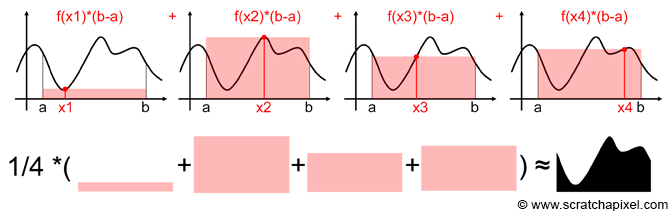

In [170]:
def MC_1dim(lower_bound, upper_bound, func, n_points):
    sum = 0
    points_local = np.random.uniform(lower_bound, upper_bound, size=n_points)

    # calculating the mean
    y_mean_sum = 0
    for x in points_local:
        y = func(x)
        y_mean_sum += y

    y_mean = y_mean_sum / n_points

    # calculating the result
    for x in points_local:
        y = func(x)
        sum += y

    result_local = (upper_bound - lower_bound)/n_points * sum

    # calculating the standard deviation
    error_sum = 0
    for x in points_local:
        error_sum += (func(x) - y_mean) ** 2

    std_error_local = (1/np.sqrt(n_points)) * np.sqrt( (1/(n_points-1)) * error_sum )

    return result_local, std_error_local

points = []

results = []
std_errors = []
abs_errors = []

trap_results = []
std_errors_trap = []
abs_errors_trap = []

range_space = range(10,10000, 10)

for n_point in range_space:
    points.append(n_point)

# monte carlo methods
for n_points in range_space:
    result, std_error = MC_1dim(lower_bound=0, upper_bound=np.pi, func=np.sin, n_points=n_points)

    results.append(result)
    std_errors.append(std_error)
    abs_errors.append(np.abs(result-2))

# trapezoid method
for n_points in range_space:

    x = np.linspace(0, np.pi, num=n_points)
    y = np.sin(x)

    result = np.trapz(y, x)

    trap_results.append(result)
    abs_errors_trap.append(np.abs(result-2))


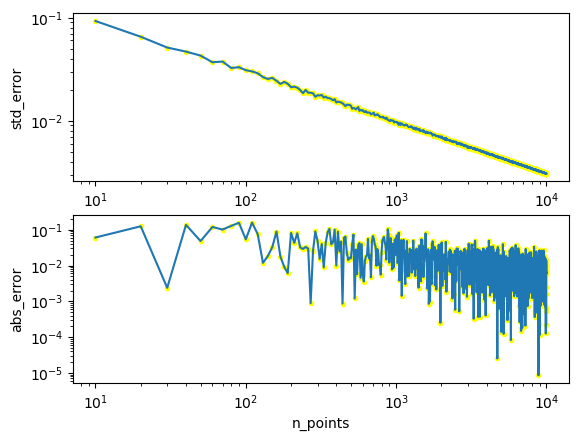

In [171]:
fig, axs = plt.subplots(2,1)

# n_point vs std_error
axs[0].scatter(points,std_errors, marker='.', color='yellow')
axs[0].plot(points, std_errors)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel('n_points')
axs[0].set_ylabel('std_error')

# n_points vs abs_error
axs[1].scatter(points, abs_errors, marker='.', color='yellow')
axs[1].plot(points, abs_errors)
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('n_points')
axs[1].set_ylabel('abs_error')

plt.show()

Explonation:
> Errors of course goes down as formula of std error dictate, but why the `abs_errro` fluctuate so much? -> becuase the method is random, so sometimes it will give better and worser results.

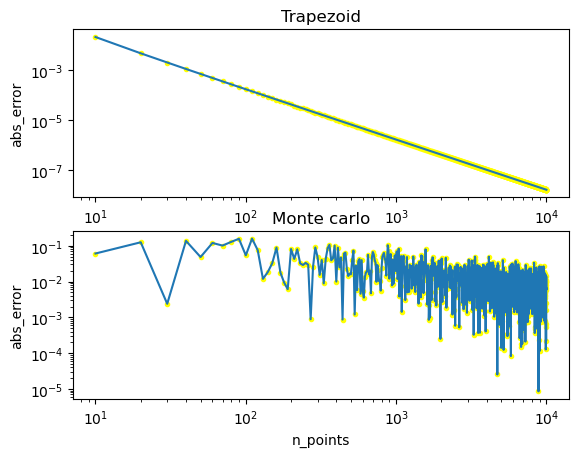

In [172]:
fig, axs = plt.subplots(2,1)

# n_point vs std_error
axs[0].scatter(points,abs_errors_trap, marker='.', color='yellow')
axs[0].plot(points, abs_errors_trap)
axs[0].set_title("Trapezoid")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel('n_points')
axs[0].set_ylabel('abs_error')

# n_points vs abs_error
axs[1].scatter(points, abs_errors, marker='.', color='yellow')
axs[1].plot(points, abs_errors)
axs[1].set_title("Monte carlo")
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('n_points')
axs[1].set_ylabel('abs_error')

plt.show()

Answear:
> Monte carlo was worser, and trapezoid was faster. Trapezoid error goes down by $O(\frac{1}{N^2})$ while mote carlo by $O(\frac{1}{\sqrt{N}})$

In [173]:
trapezoid_coeficient = -((np.log(abs_errors_trap[3]) - np.log(abs_errors_trap[4])) / (np.log(points[3]) - np.log(points[4])) )
montecarlo_coeficient = -((np.log(std_errors[3]) - np.log(std_errors[4])) / (np.log(points[3]) - np.log(points[4])) )

print(f"Trapezoid coefficient: {trapezoid_coeficient}\n Montecarlo coefficient: {montecarlo_coeficient}")

Trapezoid coefficient: 2.0460234929445003
 Montecarlo coefficient: 0.3980356204444501


## Task 4: Higher dimension integration
In n-dimension

Simple Integration:
$$I = \int_{a}^{b}\int_{a}^{b} ...\int_{a}^{b}dx_1dx_2...dx_n f(x_1,x_2,...,x_n)$$
The estimation value:
$$\bar{I} = (b-a)^n \sum_{i=0}^{N-1} \dfrac{f(x_{1i},x_{2i},...,x_{ni})}{N}.$$
**Standard error** of the estimate:
 $$ \sigma_{\bar{I}} =    \dfrac{(b-a)^n}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (f(x_{1i},x_{2i},...,x_{ni}) - \overline{f})^2}$$

+	Define a function named **MC_ndim(lower,upper,func,n_dims,n_points)** to compute the integral of an arbitrary n-dimensional fucntion using Monte Carlo method. The function should return the integral result $\bar{I}$ and the standard error $\sigma_{\bar{I}}$.
+	Using your function to compute the following integral:

	$I = \int_{0}^{\pi}\int_{0}^{\pi} sin(x_1) sin(x_2) dx_1 dx_2$

+ Compute the above integral for $n_{dims} = 5,7,9$ and plot the absolute values $|\bar{I} - 2^n|$ for these dimension values as a function of n_points using log-log scale. Does the slope of error line change when we increase the dimension ? What is your conclusion ?

In [174]:
def func_sin_2dim(x):
    return np.sin(x[0]) * np.sin(x[1])


def func_sin_ndim(x):
    return np.prod(np.sin(x))

# why those two? cuz i didnt know if i had to do the exact integral in multiple dimension, or write a new integral with sin for every dimension, so there is 2 versions

def MC_ndim(lower,upper,func,n_dims,n_points):
    sum = 0
    points_local = np.random.uniform(lower, upper, size=(n_points, n_dims))

    # calculating the mean
    y_mean_sum = 0
    for x in points_local:
        y = func(x)
        y_mean_sum += y

    y_mean = y_mean_sum / n_points

    # calculating the result
    for x in points_local:
        y = func(x)
        sum += y

    result_local = ((upper - lower)**n_dims) * (sum/n_points)

    # calculating the standard deviation
    error_sum = 0
    for x in points_local:
        error_sum += (func(x) - y_mean) ** 2

    std_error_local = ( ((upper-lower)**n_dims) / np.sqrt(n_points) ) * np.sqrt( (1/(n_points-1)) * error_sum )

    return result_local, std_error_local

In [175]:
points = []

results = {}
std_errors = {}
abs_errors = {}

range_space = range(10,1000, 10)

for n_point in range_space:
    points.append(n_point)

# monte carlo methods
n_dims = [2,5,7,9]
for n_dim in n_dims:
    results[f"{n_dim}"] = []
    std_errors[f"{n_dim}"] = []
    abs_errors[f"{n_dim}"] = []

    for n_points in range_space:
        result, std_error = MC_ndim(lower=0, upper=np.pi, func=func_sin_2dim, n_points=n_points, n_dims=n_dim)

        results[f"{n_dim}"].append(result)
        std_errors[f"{n_dim}"].append(std_error)
        abs_errors[f"{n_dim}"].append(np.abs(result-(2**n_dim)))

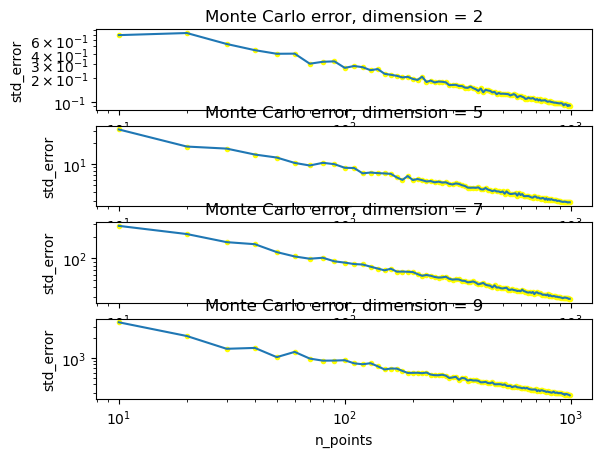

In [176]:
fig, axs = plt.subplots(4,1)

# n_point vs std_error
for i, (n_dim, std_error) in enumerate(std_errors.items()):
    axs[i].scatter(points,std_error, marker='.', color='yellow')
    axs[i].plot(points, std_error)
    axs[i].set_title(f"Monte Carlo error, dimension = {n_dim}")
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    if (i+1)%len(std_errors.keys())==0:
        axs[i].set_xlabel('n_points')
    axs[i].set_ylabel('std_error')

Explonation:
> It does change, because one component of standard error growth is exponentially to the dimension grow... ($\frac{(b-a)^n}{\sqrt{N}}$)